In [1]:
!pip install pandas scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
X, y = make_classification(
    n_samples=5000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    weights=[0.95,0.05],
    random_state=42
)

data = pd.DataFrame(X)
data["Fraud"] = y

data.head()

,0,1,2,3,4,5,6,7,8,9,Fraud
0,3.316690,-2.029674,2.355629,-0.215829,-1.419279,0.914109,-5.980685,1.518092,-0.042540,-3.397662,0
1,4.161930,-3.898558,0.174588,-0.091221,-1.360185,-0.606968,-4.648657,-2.454777,-0.667688,-0.629240,0
2,-0.477509,3.103860,2.694822,1.562327,4.191341,1.230190,3.491643,0.827346,0.635312,-2.593035,0
3,-1.894990,2.218811,-0.062834,-2.495924,-1.738007,-1.256467,-1.842087,1.668228,0.494795,-0.994083,0
4,1.060948,-0.626044,-0.793103,0.230642,2.636886,-0.128588,1.756074,-0.774238,-1.772399,0.794834,0


In [4]:
data["Fraud"].value_counts()

,count
Fraud,
0,4724
1,276


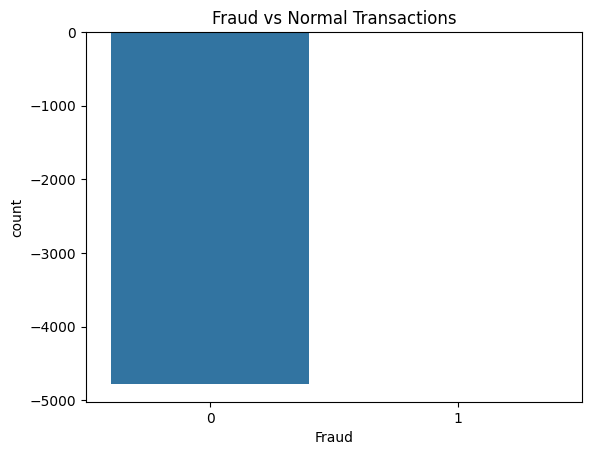

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Fraud", data=data)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [6]:
X = data.drop("Fraud", axis=1)
y = data["Fraud"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [9]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.958


In [10]:
sample = X_test.iloc[0].values.reshape(1,-1)

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Fraud Transaction Detected")
else:
    print("Legitimate Transaction")

Legitimate Transaction


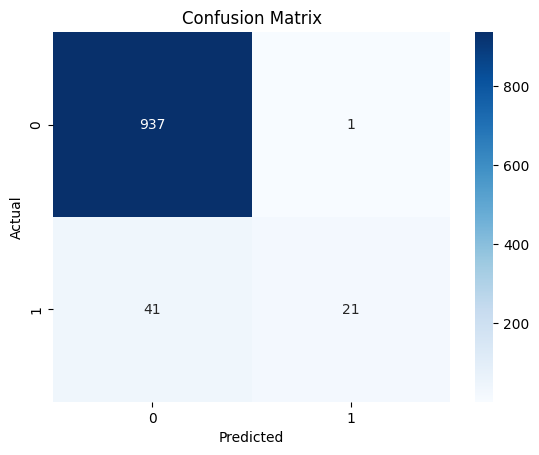

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
import joblib

joblib.dump(model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']

In [13]:
import os
os.listdir()

['.config', 'fraud_detection_model.pkl', 'sample_data']